# Spontaneous vs Task-Related Licking Neural Response Analysis

## Purpose
This notebook compares neural activity during in-trial (task-related) and out-of-trial (spontaneous) licking events. The analysis aims to determine whether neurons that respond to licks during task performance show similar activity patterns during spontaneous licking, and whether these patterns have spatial organization in the brain.

## Manuscript figure panels
- Lick-aligned PSTH comparisons (in-trial vs out-of-trial)
- PCA and CCA analysis of lick responses
- Spatial distribution of lick response properties in CCF space
- Correlation between task-related and spontaneous lick responses

## Prerequisites
- Combined unit table with quality control metrics
- Behavioral session data
- Lick detection from video and behavioral data
- CCF coordinate registration

## Environment Setup and Imports

Load all required libraries for data processing, analysis, and visualization. The custom path resolution ensures the code works regardless of where the repository is checked out.

In [1]:
import sys
import os
from matplotlib.colors import LinearSegmentedColormap
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
from pathlib import Path
import glob
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps, project_to_plane
from utils.combine_tools import apply_qc, to_str_intlike, spatial_dependence_summary
from utils.lick_utils import load_licks, load_licks_video
from utils.capsule_migration import capsule_directories
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
import warnings
from scipy.stats import gaussian_kde
import trimesh
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from utils.ccf_utils import ccf_pts_convert_to_mm
from trimesh import load_mesh
from scipy.stats import pearsonr
from aind_ephys_utils import align
warnings.filterwarnings('ignore')
capsule_dirs = capsule_directories()

%matplotlib inline
from utils.capsule_migration import CAPSULE_ROOT
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


## Analysis Configuration

Set up criteria names, version identifiers, and output directory for figure generation. This analysis uses the 'beh_all' criteria which includes all neurons passing basic quality control.

In [2]:
criteria_name = 'beh_all'
beh_criteria = 'beh_all_beh'
version = 'PrL_S1'
target_folder = os.path.join(capsule_dirs["manuscript_fig_dir"], 'F_lick_compare')
os.makedirs(target_folder, exist_ok=True)

## Load Unit and Session Data

Load the combined unit table containing all neurons across sessions, behavioral session QC metrics, and antidromic stimulation results. The antidromic data helps identify projection neurons and their targets. All data is merged on session and unit_id to create a comprehensive dataset.

In [3]:
# load basic constraints and data (unit + behavior)
with open(os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'combined_unit_tbl', 'combined_unit_tbl.pkl'), 'rb') as f:
    combined_tagged_units = pickle.load(f)
combined_tagged_units.rename(columns={'unit': 'unit_id'}, inplace=True)
combined_tagged_units['unit_id'] = combined_tagged_units['unit_id'].apply(to_str_intlike)
# behavior 
with open(os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'combined_session_tbl', 'combined_beh_sessions.pkl'), 'rb') as f:
    combined_session_qc = pickle.load(f)
combined_session_qc.drop(columns=['probe'], inplace=True, errors='ignore')
combined_tagged_units = combined_tagged_units.merge(combined_session_qc, on='session', how='left')

# antidromic data
antidromic_file = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'antidromic_analysis', version, 'combined_antidromic_results.pkl')
with open(antidromic_file, 'rb') as f:
    antidromic_df = pickle.load(f)

antidromic_df.rename(columns={'unit': 'unit_id'}, inplace=True)
antidromic_df['unit_id'] = antidromic_df['unit_id'].apply(to_str_intlike)
antidromic_df = antidromic_df[['unit_id', 'session', 'p_auto_inhi', 't_auto_inhi',
       'p_collision', 't_collision', 'p_antidromic', 't_antidromic', 'tier_1',
       'tier_2', 'tier_1_long', 'tier_2_long']].copy()
combined_tagged_units = combined_tagged_units.merge(antidromic_df, on=['session', 'unit_id'], how='left')
combined_tagged_units['tier_1'].fillna(False, inplace=True)
combined_tagged_units['tier_2'].fillna(False, inplace=True)
combined_tagged_units['tier_1_long'].fillna(False, inplace=True)
combined_tagged_units['tier_2_long'].fillna(False, inplace=True)

with open(os.path.join(CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json'), 'r') as f:
    constraints = json.load(f)
with open(os.path.join(CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics', f'{beh_criteria}.json'), 'r') as f:
    beh_constraints = json.load(f)
# start with a mask of all True
mask = pd.Series(True, index=combined_tagged_units.index)

## Load Analysis Results

Load pre-computed results from behavioral regression models, basic electrophysiology metrics, and response ratio calculations. These results will be merged with lick-aligned PSTH data later in the analysis.

In [4]:
# load model results
model_df = pd.read_csv(
    os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'outcome_regressions', f'model_combined_{criteria_name}.csv'),
    index_col=0,
)
# load basic ephys results
be_criteria = 'basic_ephys'
be_folder = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'basic_ephys')
be_file = os.path.join(be_folder, 'basic_ephys.pkl')
with open(be_file, 'rb') as f:
    basic_ephys_df = pickle.load(f)
filter = basic_ephys_df['be_filter'].values
filter = np.array(filter, dtype=bool)
basic_ephys_df['be_filter'] = filter
basic_ephys_df.rename(columns={'unit': 'unit_id'}, inplace=True)
basic_ephys_df['unit_id'] = basic_ephys_df['unit_id'].apply(to_str_intlike)

response_tbl = pd.read_csv(
    os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'response_regression', f'response_ratio_{criteria_name}_go_cue.csv')
)
response_tbl['unit_id'] = response_tbl['unit'].apply(to_str_intlike)

Applying conditional bounds for isi_violations
 - isi_violations: 15278 -> 6737 units passed
Applying items for qc_pass: [True]
 - qc_pass: 6737 -> 4497 units passed
Applying bounds for peak: [-1000, 500]
 - peak: 4497 -> 4474 units passed
Applying items for in_df: [True]
 - in_df: 4474 -> 4239 units passed
Applying conditional bounds for y_loc
 - y_loc: 4239 -> 2975 units passed
Applying bounds for trial_count: [100, 2000]
 - trial_count: 2975 -> 2961 units passed
Applying bounds for sd: [0, 0.3]
 - sd: 2961 -> 1365 units passed
Applying opto conditions: ['p_max', 'eu', 'corr', 'tag_loc', 'lat_max_p', 'p_mean', 'sig_counts']


Number of opto rows after filtering: 297
Number of non-opto rows after filtering: 1365


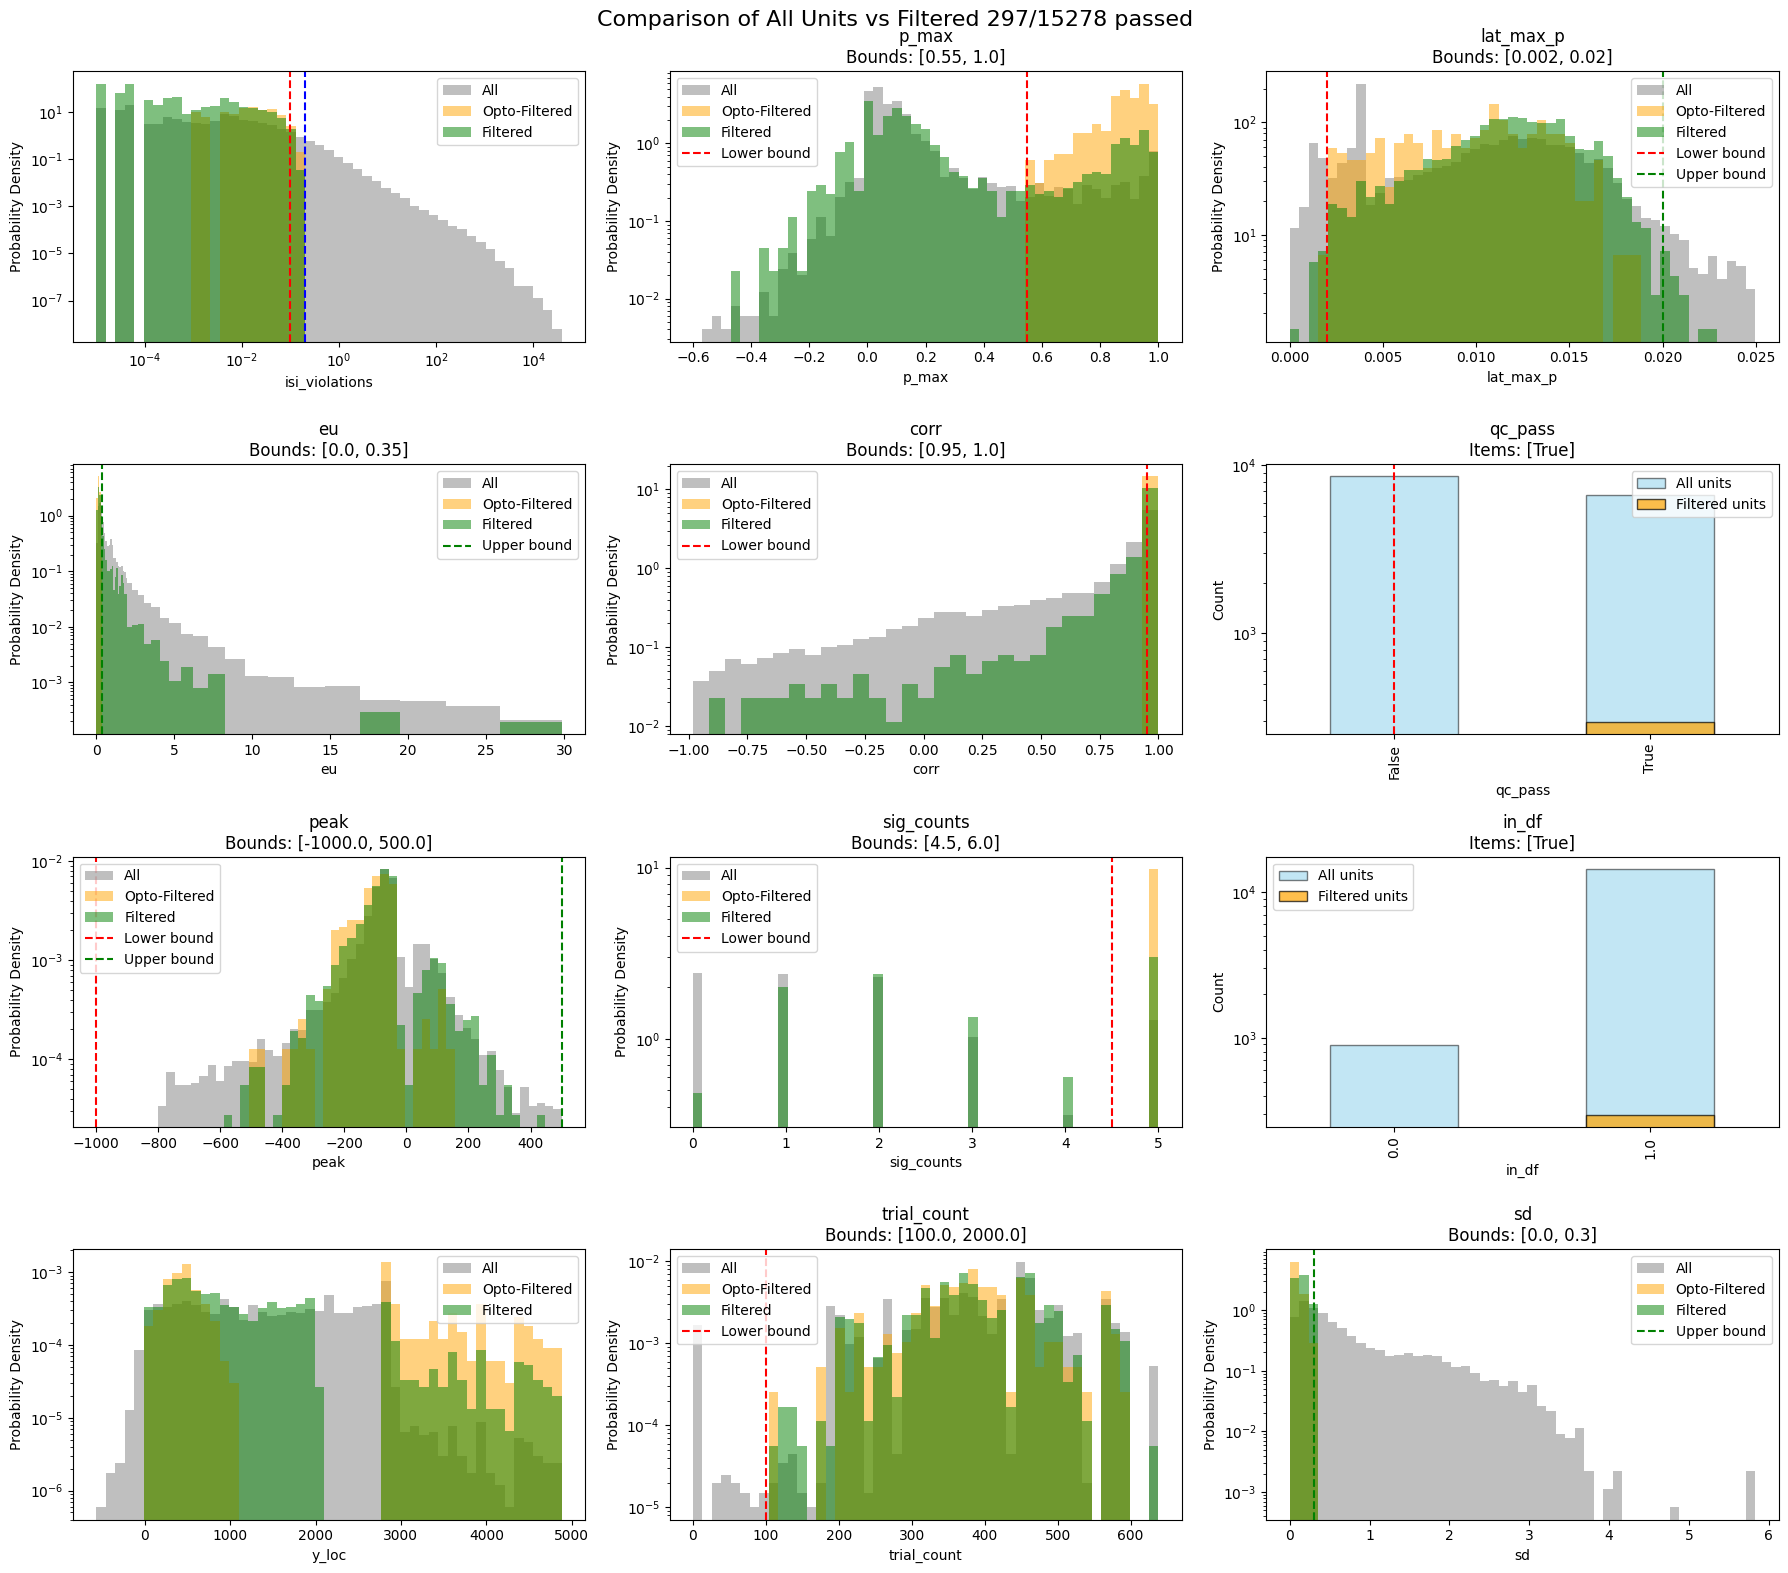

In [5]:
combined_tagged_units_filtered, combined_tagged_units, fig, axes = apply_qc(combined_tagged_units, constraints)
combined_tagged_units['unit_id'] = combined_tagged_units['unit_id'].apply(to_str_intlike)
combined_tagged_units_filtered['unit_id'] = combined_tagged_units_filtered['unit_id'].apply(to_str_intlike)

## Define Lick PSTH Computation Function

This function computes peri-stimulus time histograms (PSTHs) aligned to lick events for a given neuron. It distinguishes between:
- **In-trial licks**: Licks occurring 0-1.5s after go cue during task trials
- **Out-of-trial licks (behavior)**: Spontaneous licks detected in behavioral data
- **Out-of-trial licks (video)**: Spontaneous licks detected only in video but not behavior sensors

The function handles unit drift corrections, applies quality control cuts, and returns baseline-subtracted firing rates.

In [6]:
def get_lick_psth(session, unit_id):
    bin_size = 0.2
    step_size = 0.05
    tb = -5
    tf = 5
    loaded_session = None
    psth_in_trial = []
    psth_out_trial = []
    in_trial_period = (0, 1.5)
    session_tbl = get_session_tbl(session)
    unit_tbl = get_unit_tbl(session, data_type='curated')
    unit_tbl['unit_id'] = unit_tbl['unit_id'].apply(to_str_intlike)
    licks = load_licks_video(session)
    licks_beh = load_licks(session)
    video_loaded = True
    if licks is None:
        video_loaded = False
        licks = licks_beh


    session_dir = session_dirs(session)
    qm_dir = os.path.join(session_dir['processed_dir'], f'{session}_qm.json')
    with open(qm_dir, 'r') as f:
        qm = json.load(f)
    rec_start = qm['ephys_cut'][0]
    rec_end = qm['ephys_cut'][1]
    spike_times = unit_tbl.loc[unit_tbl['unit_id'] == unit_id, 'spike_times'].values[0]
    unit_drift = load_drift(session, unit_id)    
    session_tbl_curr = session_tbl.copy()
    spike_times_curr = spike_times.copy()
    lick_starts_L = licks['lick_trains_L']['train_starts']
    lick_starts_R = licks['lick_trains_R']['train_starts']
    lick_starts_in_trial_L = licks['lick_trains_L']['in_trial']
    lick_starts_in_trial_R = licks['lick_trains_R']['in_trial']
    L_mask = np.ones_like(lick_starts_in_trial_L, dtype=bool)
    R_mask = np.ones_like(lick_starts_in_trial_R, dtype=bool)
    L_mask &= lick_starts_L >= rec_start
    R_mask &= lick_starts_R >= rec_start
    L_mask &= lick_starts_L <= rec_end
    R_mask &= lick_starts_R <= rec_end
    if unit_drift is not None:
        if unit_drift['ephys_cut'][0] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr >= unit_drift['ephys_cut'][0]]
            session_tbl_curr = session_tbl_curr[session_tbl_curr['goCue_start_time'] >= unit_drift['ephys_cut'][0]]
            L_mask &= lick_starts_L >= unit_drift['ephys_cut'][0]
            R_mask &= lick_starts_R >= unit_drift['ephys_cut'][0]
        if unit_drift['ephys_cut'][1] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr <= unit_drift['ephys_cut'][1]]
            session_tbl_curr = session_tbl_curr[session_tbl_curr['goCue_start_time'] <= unit_drift['ephys_cut'][1]]
            L_mask &= lick_starts_L <= unit_drift['ephys_cut'][1]
            R_mask &= lick_starts_R <= unit_drift['ephys_cut'][1]
    lick_starts_L = lick_starts_L[L_mask]
    lick_starts_R = lick_starts_R[R_mask]
    lick_starts_all = np.concatenate([lick_starts_L, lick_starts_R])

    # in trial mask
    in_trial_mask = np.zeros_like(lick_starts_all, dtype=bool)

    for _, trial in session_tbl_curr.iterrows():
        trial_start = trial['goCue_start_time']
        in_trial_mask |= (lick_starts_all >= trial_start+in_trial_period[0]) & (lick_starts_all <= trial_start+in_trial_period[1])
    lick_starts_in_trial = lick_starts_all[in_trial_mask]
    lick_starts_out_trial = lick_starts_all[~in_trial_mask]

    spike_matrix_in, _ = get_spike_matrix(spike_times_curr, lick_starts_in_trial, tb, tf, bin_size, step_size, avoid_overlap = True, kernel=True, tau_rise=0.01, tau_decay=0.08)
    psth_in = np.nanmean(spike_matrix_in, axis=0)

    # has adjacent licks from behavior
    if video_loaded:
        lick_starts_beh = np.concatenate([licks_beh['lick_trains_L']['train_starts'], licks_beh['lick_trains_R']['train_starts']])
        # for lick_starts_all find if there is a beh_lick within 0.2s
        lick_close_beh_mask = np.zeros_like(lick_starts_all, dtype=bool)
        # find distance to closest beh lick
        for i, lick in enumerate(lick_starts_all):
            if len(lick_starts_beh) == 0:
                break
            closest_beh_lick = lick_starts_beh[np.argmin(np.abs(lick_starts_beh - lick))]
            if np.abs(closest_beh_lick - lick) <= 0.2:
                lick_close_beh_mask[i] = True
        lick_starts_out_trial_beh = lick_starts_all[~in_trial_mask & lick_close_beh_mask]
        lick_starts_out_trial_video = lick_starts_all[~in_trial_mask & ~lick_close_beh_mask]
        if len(lick_starts_out_trial_beh) >= 5:
            spike_matrix_out_beh, _ = get_spike_matrix(spike_times_curr, lick_starts_out_trial_beh, tb, tf, bin_size, step_size, avoid_overlap = True, kernel=True, tau_rise=0.01, tau_decay=0.08)
            psth_out_beh = np.nanmean(spike_matrix_out_beh, axis=0)
        else:
            psth_out_beh = np.full(spike_matrix_in.shape[1], np.nan)
        spike_matrix_out_beh, _ = get_spike_matrix(spike_times_curr, lick_starts_out_trial, tb, tf, bin_size, step_size, avoid_overlap = True, kernel=True, tau_rise=0.01, tau_decay=0.08)
        psth_out_beh = np.nanmean(spike_matrix_out_beh, axis=0)       
        if len(lick_starts_out_trial_video) >= 5:
            spike_matrix_out_video, _ = get_spike_matrix(spike_times_curr, lick_starts_out_trial_video, tb, tf, bin_size, step_size, avoid_overlap = True, kernel=True, tau_rise=0.01, tau_decay=0.08)
            psth_out_video = np.nanmean(spike_matrix_out_video, axis=0)
        else:
            psth_out_video = np.full(spike_matrix_in.shape[1], np.nan)
    else:
        if len(lick_starts_out_trial) >= 5:
            spike_matrix_out_beh, _ = get_spike_matrix(spike_times_curr, lick_starts_out_trial, tb, tf, bin_size, step_size, avoid_overlap = True, kernel=True, tau_rise=0.01, tau_decay=0.08)
            psth_out_beh = np.nanmean(spike_matrix_out_beh, axis=0)
            psth_out_video = np.full(spike_matrix_in.shape[1], np.nan)
        else:
            psth_out_beh = np.full(spike_matrix_in.shape[1], np.nan)
            psth_out_video = np.full(spike_matrix_in.shape[1], np.nan)



    return {'session': session, 'unit_id': unit_id, 'psth_in': psth_in, 'psth_out_beh': psth_out_beh, 'psth_out_video': psth_out_video}

## Compute Lick-Aligned PSTHs for All Units

Process all quality-controlled units in parallel to compute lick-aligned PSTHs. This parallelization significantly speeds up the analysis across the entire dataset.

In [7]:
from joblib import Parallel, delayed
results = Parallel(n_jobs=-1)(delayed(get_lick_psth)(row['session'], row['unit_id']) for _, row in combined_tagged_units_filtered.iterrows())

Lick video file not found for session behavior_758017_2025-02-04_11-57-38. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_751181_2025-02-26_11-51-19. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_754897_2025-03-13_11-20-42. Please run the lick video processing pipeline first.


Lick video file not found for session behavior_751181_2025-02-26_11-51-19. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_754897_2025-03-13_11-20-42. Please run the lick video processing pipeline first.


Lick video file not found for session behavior_751181_2025-02-26_11-51-19. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_754897_2025-03-13_11-20-42. Please run the lick video processing pipeline first.


Lick video file not found for session behavior_754897_2025-03-13_11-20-42. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_752014_2025-03-25_12-09-20. Please run the lick video processing pipeline first.


Lick video file not found for session behavior_751181_2025-02-26_11-51-19. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_754897_2025-03-13_11-20-42. Please run the lick video processing pipeline first.


...

Lick video file not found for session behavior_781166_2025-05-13_14-04-27. Please run the lick video processing pipeline first.


Lick video file not found for session behavior_758017_2025-02-04_11-57-38. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_758017_2025-02-04_11-57-38. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_754897_2025-03-13_11-20-42. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_763590_2025-05-02_11-07-09. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_781166_2025-05-16_14-16-34. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_791691_2025-06-26_13-39-26. Please run the lick video processing pipeline first.


Lick video file not found for session behavior_758017_2025-02-04_11-57-38. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_758017_2025-02-04_11-57-38. Please run the lick video processing pipeline first.


Lick video file not found for session behavior_751181_2025-02-26_11-51-19. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_754897_2025-03-13_11-20-42. Please run the lick video processing pipeline first.


Lick video file not found for session behavior_781166_2025-05-13_14-04-27. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_791691_2025-06-24_13-21-29. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_ZS061_2021-03-23_16-08-12. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_ZS061_2021-03-26_17-28-33. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_ZS061_2021-03-29_17-48-18. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_ZS061_2021-04-05_18-01-32. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_ZS061_2021-04-28_16-35-50. Please run the lick video processing pipeline first.
Lick video file not found for session behavior_ZS062_2021-04-12_18-46-29. Please run the lick video processin

## Organize and Visualize PSTH Results

Convert parallel processing results into organized arrays and perform baseline subtraction. Baseline is computed from the -5 to -1s pre-lick period. The heatmaps show neural responses aligned to lick onset, grouped by animal to visualize inter-animal variability.

In [8]:
results_df = pd.DataFrame(results)
psth_in_trial = np.array(results_df['psth_in'].tolist())
psth_out_trial = np.array(results_df['psth_out_beh'].tolist())
psth_out_trial_video = np.array(results_df['psth_out_video'].tolist())
ani_ids = [row['session'].split('_')[1] for _, row in combined_tagged_units_filtered.iterrows()]
results_df['ani_id'] = ani_ids

In [9]:
bl = np.mean(psth_in_trial[:, :20], axis=1, keepdims=True)
psth_in_trial = np.array(psth_in_trial) - bl.reshape(-1, 1)
psth_out_trial = np.array(psth_out_trial) - bl.reshape(-1, 1)
psth_out_trial_video = np.array(psth_out_trial_video) - bl.reshape(-1, 1)

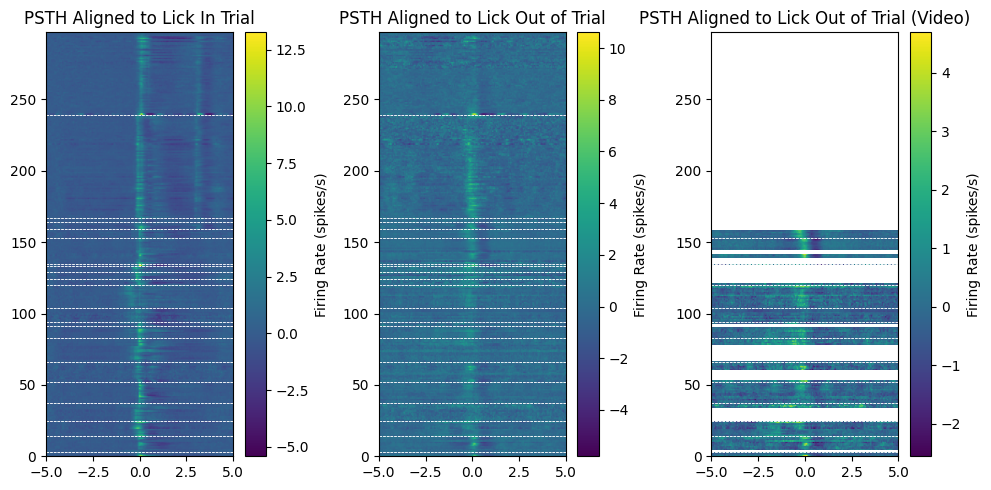

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
psth_in_trial = np.array(psth_in_trial)
psth_out_trial = np.array(psth_out_trial)
bin_size = 0.2
step_size = 0.05
tb = -5
tf = 5
#
im1 = ax[0].imshow(psth_in_trial, aspect='auto', extent=[tb, tf, 0, psth_in_trial.shape[0]], origin='lower')
ax[0].set_title('PSTH Aligned to Lick In Trial')
# draw vertical line between each animal
ani_ind_list = results_df['ani_id'].values
for ani_id in np.unique(ani_ind_list):
    ani_inds = np.where(ani_ind_list == ani_id)[0]
    ax[0].axhline(ani_inds[0], color='w', linestyle='--', linewidth=0.5)
    ax[0].axhline(ani_inds[-1]+1, color='w', linestyle='--', linewidth=0.5)

im2 = ax[1].imshow(psth_out_trial, aspect='auto', extent=[tb, tf, 0, psth_out_trial.shape[0]], origin='lower')
ax[1].set_title('PSTH Aligned to Lick Out of Trial')
for ani_id in np.unique(ani_ind_list):
    ani_inds = np.where(ani_ind_list == ani_id)[0]
    ax[1].axhline(ani_inds[0], color='w', linestyle='--', linewidth=0.5)
    ax[1].axhline(ani_inds[-1]+1, color='w', linestyle='--', linewidth=0.5)

im3 = ax[2].imshow(psth_out_trial_video, aspect='auto', extent=[tb, tf, 0, psth_out_trial_video.shape[0]], origin='lower')
ax[2].set_title('PSTH Aligned to Lick Out of Trial (Video)')
for ani_id in np.unique(ani_ind_list):
    ani_inds = np.where(ani_ind_list == ani_id)[0]
    ax[2].axhline(ani_inds[0], color='w', linestyle='--', linewidth=0.5)
    ax[2].axhline(ani_inds[-1]+1, color='w', linestyle='--', linewidth=0.5)
fig.colorbar(im1, ax=ax[0], label='Firing Rate (spikes/s)')
fig.colorbar(im2, ax=ax[1], label='Firing Rate (spikes/s)')
fig.colorbar(im3, ax=ax[2], label='Firing Rate (spikes/s)')

plt.tight_layout()

## Extract Peak Response Metrics

For each neuron, extract summary statistics from the PSTH:
- Peak firing rate in the -1 to 0.5s peri-lick window
- Latency to peak response
- Rise from baseline to peak

These metrics are computed for both in-trial and out-of-trial licks, then merged with PCA/CCA scores and previously computed behavioral/electrophysiology results to create a comprehensive feature table.

In [11]:
# cal peak and peak lat for psth_in and psth_out
def cal_peak_latency(psth, time_vector, search_window, base_window):
    peak_vals = []
    peak_lats = []
    rise_vals = []
    for i in range(psth.shape[0]):
        window_mask = (time_vector >= search_window[0]) & (time_vector <= search_window[1])
        base_mask = (time_vector >= base_window[0]) & (time_vector <= base_window[1])
        psth_window = psth[i, window_mask]
        time_window = time_vector[window_mask]
        time_base = time_vector[base_mask]
        if len(psth_window) == 0:
            peak_vals.append(np.nan)
            peak_lats.append(np.nan)
            rise_vals.append(np.nan)
            continue
        peak_val = np.max(psth_window)
        peak_lat = time_window[np.argmax(psth_window)]
        baseline = np.mean(psth[i, base_mask])
        peak_vals.append(peak_val)
        peak_lats.append(peak_lat)
        rise_vals.append(peak_val - baseline)
    return np.array(peak_vals), np.array(peak_lats), np.array(rise_vals)
time_vector = np.linspace(tb, tf, psth_in_trial.shape[1])
search_window = (-1, 0.5)
base_window = (-2, -1)
peak_vals_in, peak_lats_in, rise_in = cal_peak_latency(psth_in_trial, time_vector, search_window, base_window)
peak_vals_out, peak_lats_out, rise_out = cal_peak_latency(psth_out_trial, time_vector, search_window, base_window)
peak_vals_out_video, peak_lats_out_video, rise_out_video = cal_peak_latency(psth_out_trial_video, time_vector, search_window, base_window)  
# add to results df
results_df['peak_val_in'] = peak_vals_in
results_df['peak_lat_in'] = peak_lats_in
results_df['peak_val_out_video'] = peak_vals_out_video
results_df['peak_val_out'] = peak_vals_out
results_df['peak_lat_out'] = peak_lats_out
results_df['peak_lat_out_video'] = peak_lats_out_video
results_df['rise_in'] = rise_in
results_df['rise_out'] = rise_out
results_df['rise_out_video'] = rise_out_video
results_df['peak_in-out_diff'] = (results_df['peak_val_in'] - results_df['peak_val_out'])
results_df['lat_in-out_diff'] = results_df['peak_lat_in'] - results_df['peak_lat_out']


In [12]:
# results_df = results_df.merge(combined_tagged_units_filtered, on=['session', 'unit_id'], how='left')
# append behavior model results and basic ephys results
results_df = results_df.merge(model_df, on=['session', 'unit_id'], how='left')
results_df = results_df.merge(basic_ephys_df, on=['session', 'unit_id'], how='left')
results_df = results_df.merge(response_tbl, on=['session', 'unit_id'], how='left')
results_df = results_df.merge(combined_tagged_units_filtered[['session', 'unit_id', 'x_ccf', 'y_ccf', 'z_ccf']], on=['session', 'unit_id'], how='left')

## Prepare CCF Spatial Mapping

Load the Common Coordinate Framework (CCF) brain mesh and set up coordinate transformations. This enables visualization of neural properties in standardized 3D brain space and projection onto 2D anatomical planes (sagittal, horizontal, coronal). Coordinates are converted to the LPS coordinate system and referenced to bregma.

In [13]:
features_to_plot = ['peak_val_in', 'peak_val_out', 'peak_val_out_video',
                    'peak_lat_in', 'peak_lat_out', 'peak_lat_out_video', 
                    'peak_in-out_diff', 'lat_in-out_diff', 'rise_in', 'rise_out', 'rise_out_video']

## Spatial Dependence Analysis

Test whether lick response properties have spatial organization in the brain. For each feature, perform:
- **KNN regression**: Tests if nearby neurons have similar feature values
- **Linear trend analysis**: Tests for systematic gradients across brain regions
- **Permutation testing**: Establishes statistical significance by shuffling spatial locations

Results are visualized as anatomical projections with color-coded feature values and arrows indicating gradient directions.

In [14]:
spatial_dependence_results = {}
# --- 3D anatomical points ---
ccfs = results_df[['x_ccf', 'y_ccf', 'z_ccf']].values
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
ccfs = ccfs - bregma_LPS_mm
ml, ap, dv = 0, 1, 2
mask = ~np.isnan(ccfs).any(axis=1)  # mask for valid ccf points
ccfs[:, ml] = np.abs(ccfs[:, ml])  # mirror ML to left hemisphere
for feature in features_to_plot:
    values = results_df[feature].values.astype(float)
    result = spatial_dependence_summary(
        ccfs[mask, :],
        values[mask],
        k_neighbors=30,
        n_splits=5,
        permutations=2000,
        seed=42,
    )
    spatial_dependence_results[feature] = result


In [15]:
# # multiple comparison correction (FDR)
# from statsmodels.stats.multitest import multipletests
# # for knn
# p_values = [spatial_dependence_results[feat]['cv_predictability_knn']['p_value_permutation'] for feat in results_df.columns if feat in spatial_dependence_results.keys()]
# reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
# for i, feature_name in spatial_dependence_results.keys():
#     spatial_dependence_results[feature_name]['cv_predictability_knn']['p_value_permutation_fdr'] = pvals_corrected[i]
#     spatial_dependence_results[feature_name]['cv_predictability_knn']['significant_fdr'] = reject[i]
# # for trend
# p_values = [spatial_dependence_results[feat]['linear_trend']['p_value_permutation_r2'] for feat in feature_map.keys()]
# reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
# for i, feature_name in spatial_dependence_results.keys():
#     spatial_dependence_results[feature_name]['linear_trend']['p_value_permutation_r2_fdr'] = pvals_corrected[i]
#     spatial_dependence_results[feature_name]['linear_trend']['significant_fdr'] = reject[i]
# save results
output_file = os.path.join(target_folder, f'spatial_dependence_results_{criteria_name}.pkl')
with open(output_file, 'wb') as f:
    pickle.dump(spatial_dependence_results, f)

## Save and Load Results

Save the complete results dataframe containing all computed features for reuse in subsequent analyses and figure generation.

In [16]:
# save _results_df as pkl
output_file = os.path.join(target_folder, f'lick_psth_combined_results_{criteria_name}.pkl')
with open(output_file, 'wb') as f:
    pickle.dump(results_df, f)

In [17]:
# load results_df
output_file = os.path.join(target_folder, f'lick_psth_combined_results_{criteria_name}.pkl')
with open(output_file, 'rb') as f:
    results_df = pickle.load(f)

## Correlation Analysis Between Features

Generate scatter plots to examine relationships between:
- In-trial vs out-of-trial peak responses
- Task-related response properties vs behavioral regression coefficients
- Spatial PC loadings vs response magnitudes

These visualizations reveal whether neurons with strong task-related lick responses also respond to spontaneous licks, and how lick responses relate to other neural properties.

['/root/capsule/scratch/results/manuscript/figures/F_lick_compare/FigureS15q_peak_val_in_peak_val_out_comparison_beh_all.csv']

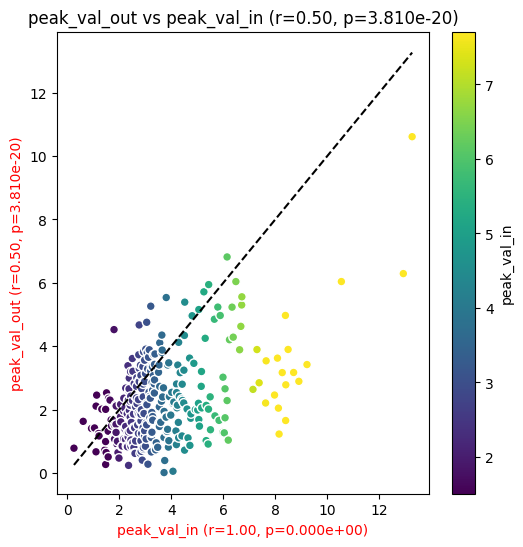

In [18]:
color_code = 'peak_val_in'


# Create jointplot (it creates its own figure)
fig = plt.figure(figsize=(6, 6))
sort_ind = np.argsort(results_df[color_code].values)
# sort_ind = np.random.permutation(sort_ind)  # shuffle to prevent overplotting bias
x_val = 'peak_val_in'
y_val = 'peak_val_out'
g = plt.scatter(results_df[x_val][sort_ind], results_df[y_val][sort_ind], alpha=1, edgecolors='w', 
                c=results_df[color_code][sort_ind], cmap='viridis', s = 40,
                vmin=np.nanquantile(results_df[color_code].values, 0.05), vmax=np.nanquantile(results_df[color_code].values, 0.95))
plt.plot([results_df[x_val].min(), results_df[x_val].max()], [results_df[x_val].min(), results_df[x_val].max()], 'k--')
plt.colorbar(g, label=color_code)
# check if x and y correlate with colorcode. label on x and y axis
filter = ~np.isnan(results_df[x_val]) & ~np.isnan(results_df[color_code])& ~np.isnan(results_df[y_val])

corr_x = pearsonr(results_df[x_val][filter], results_df[color_code][filter])
corr_y = pearsonr(results_df[y_val][filter], results_df[color_code][filter])

# calculate p value

p_x = pearsonr(results_df[x_val][filter], results_df[color_code][filter])[1]
p_y = pearsonr(results_df[y_val][filter], results_df[color_code][filter])[1]

if p_x < 0.05:
    plt.xlabel(f'{x_val} (r={corr_x[0]:.2f}, p={p_x:.3e})', color='red')
else:
    plt.xlabel(f'{x_val} (r={corr_x[0]:.2f}, p={p_x:.3e})', color='black')

if p_y < 0.05:
    plt.ylabel(f'{y_val} (r={corr_y[0]:.2f}, p={p_y:.3e})', color='red')
else:
    plt.ylabel(f'{y_val} (r={corr_y[0]:.2f}, p={p_y:.3e})', color='black')

corr_xy = pearsonr(results_df[x_val][filter], results_df[y_val][filter])
plt.title(f'{y_val} vs {x_val} (r={corr_xy[0]:.2f}, p={corr_xy[1]:.3e})')
save_panels(fig, target_folder, f'{x_val}_{y_val}_comparison_{criteria_name}', ['FigureS15q'], exts=('svg',), bbox_inches='tight', dpi=300)
# ---- panel CSV (rule 1: scatter with gradient) ----
save_panel_csv(columns_to_df(**{'peak_val_in': results_df['peak_val_in'].values, 'peak_val_out': results_df['peak_val_out'].values, 'pc_1': results_df['pc_1'].values}), target_folder, f'{x_val}_{y_val}_comparison_{criteria_name}', ['FigureS15q'])
##FigureS15q##
